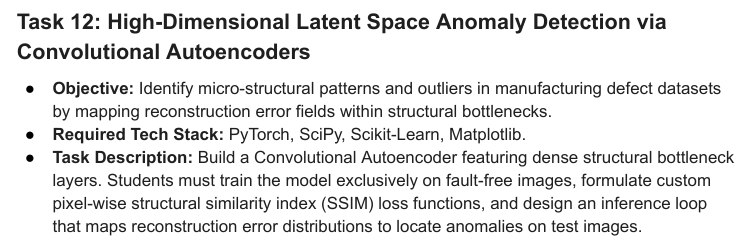

In [1]:
!pip install torch torchvision scipy scikit-learn matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from scipy.ndimage import gaussian_filter

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.15MB/s]


In [5]:
normal_class = 0

normal_images = []

for image, label in train_dataset:

    if label == normal_class:
        normal_images.append(image)

normal_images = torch.stack(
    normal_images
)

print(
    "Normal training images:",
    normal_images.shape
)

Normal training images: torch.Size([5923, 1, 28, 28])


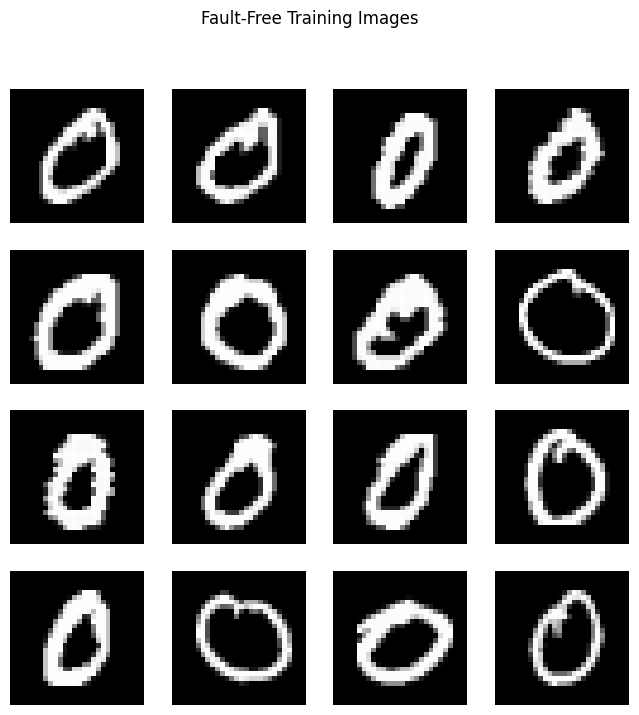

In [6]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        normal_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Fault-Free Training Images"
)

plt.show()

In [7]:
normal_loader = torch.utils.data.DataLoader(
    normal_images,
    batch_size=64,
    shuffle=True
)

In [8]:
class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU()
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Linear(
            64 * 7 * 7,
            128
        )

    def forward(self, x):

        x = self.conv(x)

        x = self.flatten(x)

        x = self.fc(x)

        return x

In [9]:
class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc = nn.Linear(
            128,
            64 * 7 * 7
        )

        self.deconv = nn.Sequential(

            nn.ConvTranspose2d(
                64,
                32,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                32,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Sigmoid()
        )

    def forward(self, z):

        x = self.fc(z)

        x = x.view(
            -1,
            64,
            7,
            7
        )

        x = self.deconv(x)

        return x

In [10]:
class ConvAutoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = Encoder()

        self.decoder = Decoder()

    def forward(self, x):

        latent = self.encoder(x)

        reconstruction = self.decoder(
            latent
        )

        return reconstruction, latent

In [11]:
model = ConvAutoencoder().to(device)

print(model)

ConvAutoencoder(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc): Linear(in_features=3136, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=128, out_features=3136, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): Sigmoid()
    )
  )
)


In [12]:
sample = normal_images[
    :8
].to(device)

reconstructed, latent = model(
    sample
)

print(
    "Input:",
    sample.shape
)

print(
    "Latent:",
    latent.shape
)

print(
    "Reconstruction:",
    reconstructed.shape
)

Input: torch.Size([8, 1, 28, 28])
Latent: torch.Size([8, 128])
Reconstruction: torch.Size([8, 1, 28, 28])


In [13]:
def ssim_loss(
    img1,
    img2,
    window_size=3
):

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu1 = F.avg_pool2d(
        img1,
        window_size,
        stride=1,
        padding=window_size // 2
    )

    mu2 = F.avg_pool2d(
        img2,
        window_size,
        stride=1,
        padding=window_size // 2
    )

    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2

    mu1_mu2 = mu1 * mu2

    sigma1_sq = (
        F.avg_pool2d(
            img1 ** 2,
            window_size,
            stride=1,
            padding=window_size // 2
        )
        -
        mu1_sq
    )

    sigma2_sq = (
        F.avg_pool2d(
            img2 ** 2,
            window_size,
            stride=1,
            padding=window_size // 2
        )
        -
        mu2_sq
    )

    sigma12 = (
        F.avg_pool2d(
            img1 * img2,
            window_size,
            stride=1,
            padding=window_size // 2
        )
        -
        mu1_mu2
    )

    ssim = (
        (2 * mu1_mu2 + C1)
        *
        (2 * sigma12 + C2)
    ) / (
        (mu1_sq + mu2_sq + C1)
        *
        (sigma1_sq + sigma2_sq + C2)
        + 1e-8
    )

    return 1 - ssim.mean()

In [14]:
loss = ssim_loss(
    sample,
    reconstructed
)

print(
    "SSIM Loss:",
    loss.item()
)

SSIM Loss: 0.9845598936080933


In [15]:
def reconstruction_loss(
    original,
    reconstructed
):

    mse = F.mse_loss(
        reconstructed,
        original
    )

    ssim = ssim_loss(
        original,
        reconstructed
    )

    return mse + ssim

In [16]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [18]:
loss_history = []

epochs = 3

model.train()

for epoch in range(epochs):

    total_loss = 0

    for images in normal_loader:

        images = images.to(device)

        reconstructed, latent = model(
            images
        )

        loss = reconstruction_loss(
            images,
            reconstructed
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss /
        len(normal_loader)
    )

    loss_history.append(
        average_loss
    )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/3 Loss: 0.5171
Epoch 2/3 Loss: 0.5169
Epoch 3/3 Loss: 0.5155


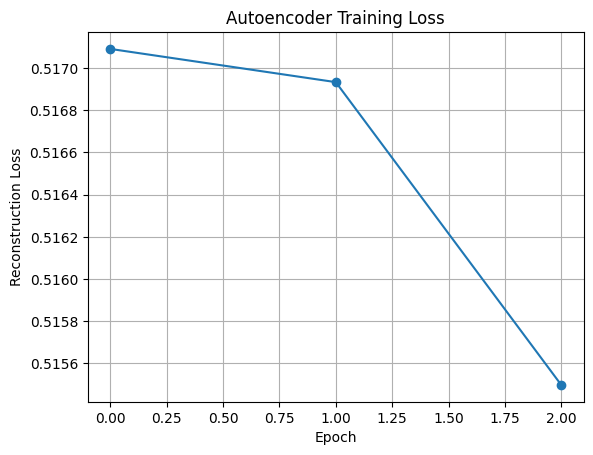

In [19]:
plt.plot(
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Reconstruction Loss")

plt.title(
    "Autoencoder Training Loss"
)

plt.grid()

plt.show()

In [20]:
model.eval()

with torch.no_grad():

    reconstructed, latent = model(
        sample
    )

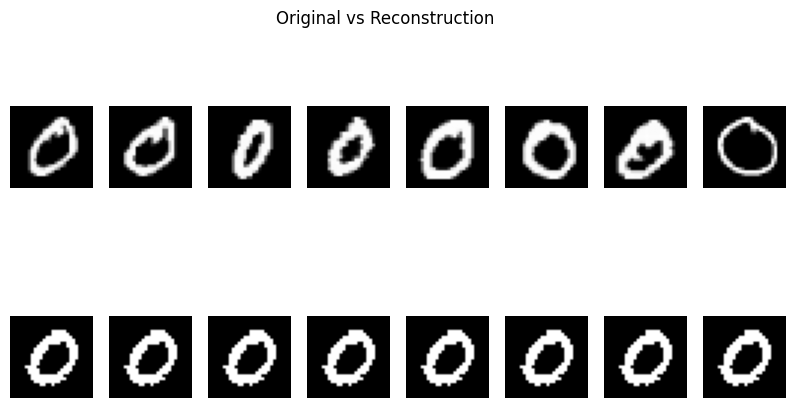

In [21]:
plt.figure(figsize=(10, 5))

for i in range(8):

    # Original
    plt.subplot(2, 8, i + 1)

    plt.imshow(
        sample[i].cpu().squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    # Reconstruction
    plt.subplot(
        2,
        8,
        i + 9
    )

    plt.imshow(
        reconstructed[i]
        .cpu()
        .squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Original vs Reconstruction"
)

plt.show()

In [22]:
def reconstruction_error(
    original,
    reconstructed
):

    error = torch.abs(
        original - reconstructed
    )

    return error

In [23]:
normal_test_images = []

normal_test_labels = []

for image, label in test_dataset:

    if label == 0:

        normal_test_images.append(
            image
        )

        normal_test_labels.append(0)

In [24]:
anomaly_test_images = []

anomaly_test_labels = []

for image, label in test_dataset:

    if label != 0:

        anomaly_test_images.append(
            image
        )

        anomaly_test_labels.append(1)

In [25]:
test_images = torch.stack(
    normal_test_images +
    anomaly_test_images
)

test_labels = np.array(
    normal_test_labels +
    anomaly_test_labels
)

print(
    "Test images:",
    test_images.shape
)

print(
    "Labels:",
    test_labels.shape
)

Test images: torch.Size([10000, 1, 28, 28])
Labels: (10000,)


In [26]:
anomaly_scores = []

model.eval()

with torch.no_grad():

    for i in range(
        0,
        len(test_images),
        64
    ):

        batch = test_images[
            i:i+64
        ].to(device)

        reconstruction, _ = model(
            batch
        )

        errors = torch.mean(
            torch.abs(
                batch - reconstruction
            ),
            dim=(1, 2, 3)
        )

        anomaly_scores.extend(
            errors.cpu().numpy()
        )

In [27]:
normal_scores = np.array(
    anomaly_scores
)[
    test_labels == 0
]

threshold = np.percentile(
    normal_scores,
    95
)

print(
    "Anomaly threshold:",
    threshold
)

Anomaly threshold: 0.19174871


In [28]:
predictions = (
    np.array(anomaly_scores)
    > threshold
).astype(int)

In [29]:
auc = roc_auc_score(
    test_labels,
    anomaly_scores
)

print(
    "ROC-AUC:",
    auc
)

ROC-AUC: 0.948438617131997


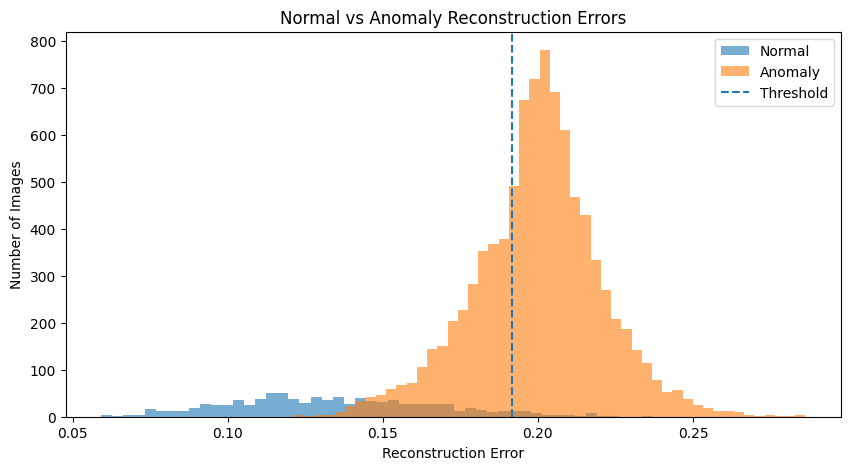

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(
    normal_scores,
    bins=50,
    alpha=0.6,
    label="Normal"
)

anomaly_scores_array = np.array(
    anomaly_scores
)[
    test_labels == 1
]

plt.hist(
    anomaly_scores_array,
    bins=50,
    alpha=0.6,
    label="Anomaly"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="Threshold"
)

plt.xlabel(
    "Reconstruction Error"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Normal vs Anomaly Reconstruction Errors"
)

plt.legend()

plt.show()

In [31]:
anomaly_index = np.argmax(
    np.array(anomaly_scores)
)

anomaly_image = test_images[
    anomaly_index
].unsqueeze(0).to(device)

In [32]:
with torch.no_grad():

    anomaly_reconstruction, _ = model(
        anomaly_image
    )

In [33]:
error_map = torch.abs(
    anomaly_image
    -
    anomaly_reconstruction
)

error_map = (
    error_map
    .squeeze()
    .cpu()
    .numpy()
)

In [34]:
smooth_error = gaussian_filter(
    error_map,
    sigma=1
)

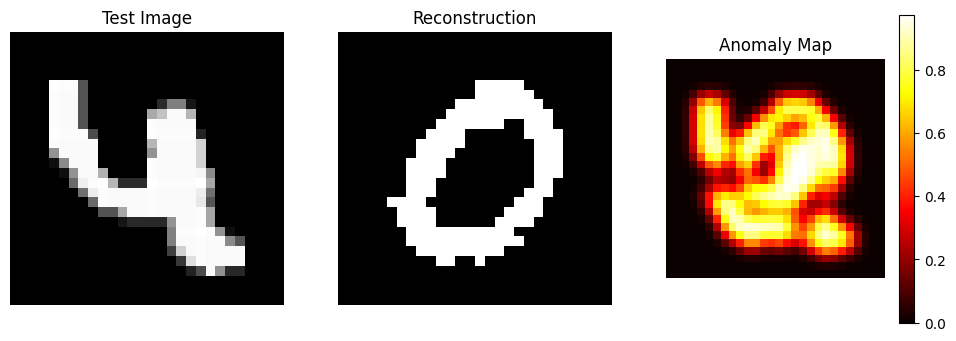

In [35]:
plt.figure(figsize=(12, 4))

# Original
plt.subplot(1, 3, 1)

plt.imshow(
    anomaly_image.cpu().squeeze(),
    cmap="gray"
)

plt.title("Test Image")

plt.axis("off")


# Reconstruction
plt.subplot(1, 3, 2)

plt.imshow(
    anomaly_reconstruction
    .cpu()
    .squeeze(),
    cmap="gray"
)

plt.title("Reconstruction")

plt.axis("off")


# Error map
plt.subplot(1, 3, 3)

plt.imshow(
    smooth_error,
    cmap="hot"
)

plt.colorbar()

plt.title(
    "Anomaly Map"
)

plt.axis("off")

plt.show()

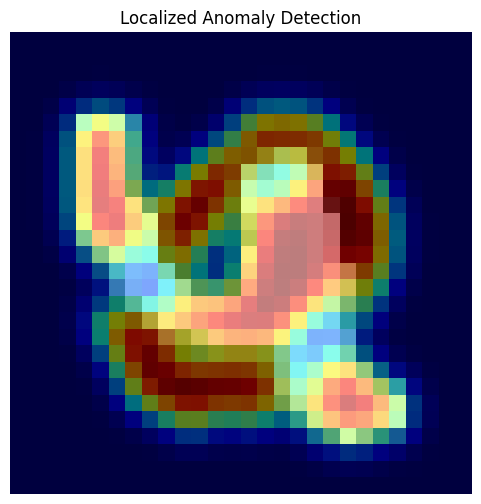

In [36]:
plt.figure(figsize=(6, 6))

plt.imshow(
    anomaly_image.cpu().squeeze(),
    cmap="gray"
)

plt.imshow(
    smooth_error,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "Localized Anomaly Detection"
)

plt.axis("off")

plt.show()